# Analiza delnic

Na več načinov bom analiziral največjih 500 delnic na svetovnem trgu, na njih izvedel hitre Fourierove transformacije in primerjal kako se skupaj primerjajo z indeksom S&P 500, ki naj bi posnemal njihovo obnašanje. <br>
Uporabljal bom podatke iz obdobja enega leta (od 1. julija 2025 do 1. julija 2026), ki sem jih pridobil s spletne strani Yahoo finance. <br>
Za podatke sem si izbral adjusted close price vseh delnic za vsak dan, ko je bila borza odprta, ter market cap, Beta marker in P/E razmerje vseh delnic 1.julija 2026, ko sem podatke pridobil s spleta.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

### Izvedimo najprej hitre Fourierove transformacije na indeksu S&P 500:


In [ ]:
CENE_SP_500 = pd.read_csv("SP_500_cene.csv")
CENE_SP_500_STOLPCI = CENE_SP_500.T.reset_index()
CENE_SP_500_STOLPCI.columns = ["Datum", "Cena"]
CENE_SP_500_STOLPCI = CENE_SP_500_STOLPCI.drop(0).reset_index(drop=True)
CENE_SP_500_STOLPCI["Cena"] = CENE_SP_500_STOLPCI["Cena"].str.replace(",", "")

CENE_SP_500_STOLPCI["Datum"] = pd.to_datetime(CENE_SP_500_STOLPCI["Datum"])
CENE_SP_500_STOLPCI["Cena"] = CENE_SP_500_STOLPCI["Cena"].astype(float)

# Izračunamo razliko med podatki
CENE_SP_500_STOLPCI["Donos"] = CENE_SP_500_STOLPCI["Cena"].pct_change()

donosi_cisti = CENE_SP_500_STOLPCI["Donos"].dropna().values
stevilo_trgovalnih_dni = len(donosi_cisti)


fft_vrednosti = fft(donosi_cisti)
frekvence = fftfreq(stevilo_trgovalnih_dni, d=1)

# Jemljemo le pozitivne frekvence, saj je FFT vedmo simetričen
pozitivni_indeksi = frekvence > 0
f_prave = frekvence[pozitivni_indeksi]

# Izračunamo moč posamezne frekvence
amplitude = np.abs(fft_vrednosti[pozitivni_indeksi])

# Frekvence pretvorimo v periode: perioda = 1 / frekvenca
periode = 1 / f_prave

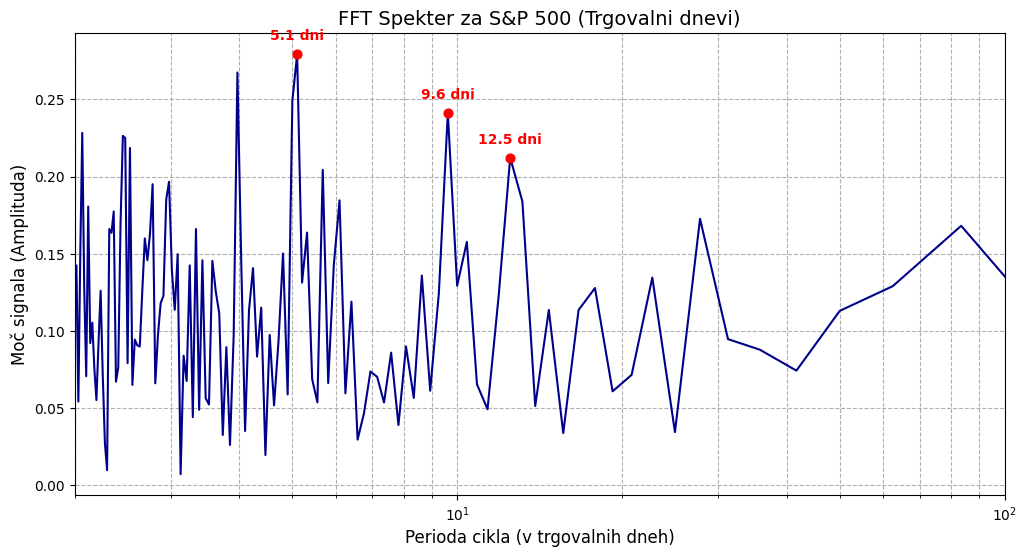

In [ ]:
# Prikažimo graf - napisano s pomočjo umetne inteligence
plt.figure(figsize=(12, 6))
plt.plot(periode, amplitude, color="darkblue", linewidth=1.5)
plt.xscale("log")
plt.title("FFT Spekter za S&P 500 (Trgovalni dnevi)", fontsize=14)
plt.xlabel("Perioda cikla (v trgovalnih dneh)", fontsize=12)
plt.ylabel("Moč signala (Amplituda)", fontsize=12)
plt.grid(True, which="both", ls="--")
plt.xlim(2, 100)

indeksi_nad_5d = periode > 5
if np.any(indeksi_nad_5d):
    najvisji_vrhovi = np.argsort(amplitude[indeksi_nad_5d])[-3:]
    for idx in najvisji_vrhovi:
        p_vrh = periode[indeksi_nad_5d][idx]
        a_vrh = amplitude[indeksi_nad_5d][idx]
        plt.scatter(p_vrh, a_vrh, color="red", s=40, zorder=5)
        plt.annotate(
            f"{p_vrh:.1f} dni",
            (p_vrh, a_vrh),
            textcoords="offset points",
            xytext=(0, 10),
            ha="center",
            fontweight="bold",
            color="red",
        )


plt.show()

Iz grafa so razvidni najmočnejši signali (frekvence) gibanja cene indeksa S&P 500, ki so večji od 5-ih dni (da se izognemo dnevnemu šumu) <br>
Vidimo lahko, da so najmočnejši signali 5,1 dni, 9,6 dni in 12,5 dni. Poglejmo si vsakega posebej:

- Signal 5,1 dni je znan tudi kot tedenski cikel (Weekly Cycle). Ta obstaja zaradi tradicije in razmišljanja institucij, ki trgujejo z delnicami. Pogosto se kratkoročne pozicije vzpostavljajo ob ponedeljkih, zapirajo pa ob petkih (da se izogneju vikendskemu tveganju - weekend effect). Poleg tega se vsak petek izvedejo še druge pomembne tedenske dejavnosti, kot na primer tedenski opcijski trg (weekly options), zaradi katerih morajo podjetja uravnotežiti svoje portfelje (delta hedging).

- Signal 9,6 dni je znan tudi kot dvotedenski cikel (Bi-weekly Cycle). Ta je močan, ker v Ameriki večino podjetij izplačuje plače delavcem na dva tedna (bi-weekly payroll), na ta signal pa imajo vpliv tudi algoritemski sistemi, ki uporabljajo 10-dnevno povprečje.

- Signal 12,5 dni pa je nekoliko bolj nenavaden - gre za t.i. Gamma cikel ali Fibonaccijev ritem. Njegova pojavitev je posledica uporabe kvantitativnih skladov in algoritmov Fibonaccijevega števila 13 (skladi in algoritmi se pogosto opirajo na Fibonaccijeva števila). Poleg tega ima velik vpliv tudi polmesečni učinek - veliko podjetij prilagaja svoj portfelij dvakrat mesečno, običajno enkrat 1. v mesecu in enkrat 15. v mesecu - v trgovalnih dnevih to pomeni ravno okrog 12 dni razlike.


### Sledi Fourierova Ekstrapolacija indeksa S&P 500:

Fourierova ekstrapolacija poteka v več korakih korakih, in sicer:

1. izluščimo že znane podatke o ceni delnic
2. odstranimo trend (dolgoročno trg raste, zato ta trend izračunamo in odstranimo)
3. izvedemo FFT in poiščemo n najmočnejših frekvenc
4. ekstrapoliramo v prihodnost
5. združimo sedanje in prihodnje podatke ter prikažemo v grafu


In [ ]:
# Najprej izluščimo že dobljene podatke:
predvidevane_cene = CENE_SP_500_STOLPCI.sort_values("Datum").reset_index(drop=True)
y = predvidevane_cene["Cena"].values
stevilo_dni = len(y)
x = np.arange(stevilo_dni)

# Poiščemo dolgotranji trend in ga odstranimo
# Polyfit poišče najbolj 'ustrezen' polinom željene stopnje, ki se prilega podatkom-tukaj bo to premica
koeficienti_trenda = np.polyfit(x, y, 1)
trend = np.polyval(koeficienti_trenda, x)
y_brez_trenda = y - trend

# Pa dobljenem y-u izvedemo FFT in poiščemo frekvence
y_fft = np.fft.fft(y_brez_trenda)
frekvence = np.fft.fftfreq(stevilo_dni)

# Izberemo si koliko frekvenc želimo vzeti - to lahko spreminjamo po želji
stevilo_izbranih_frekvenc = 50
indeksi = np.argsort(np.abs(y_fft))[::-1]

# Izberemo koliko dni v prihodnost želimo podaljšati graf
dnevi_v_prihodnost = 100
x_prihodnost = np.arange(stevilo_dni + dnevi_v_prihodnost)

# Izvedba ekstrapolacije:
# Najprej moramo ustvariti prazen signal za preteklost + prihodnost
rekonstrukcija = np.zeros(len(x_prihodnost))

for index in indeksi[:stevilo_izbranih_frekvenc]:
    amplituda = np.abs(y_fft[index]) / stevilo_dni
    faza = np.angle(y_fft[index])
    f = frekvence[index]
    if f == 0:
        množitelj = 1
    else:
        množitelj = 2

    rekonstrukcija += (
        množitelj * amplituda * np.cos(2 * np.pi * f * x_prihodnost + faza)
    )

# Sedaj prištejemo nazaj trend - to je trend od prej, le podaljšan v prihodnost
trend_prihodnost = np.polyval(koeficienti_trenda, x_prihodnost)
končna_napoved = rekonstrukcija + trend_prihodnost

# Pred izrisom grafa moramo še določiti prihodnje datume, na katere bo borza odprta
# Ta del kode za podaljšanje datumov sem pridobil iz interneta
zadnji_datum = predvidevane_cene["Datum"].max()
prihodnji_datumi = pd.bdate_range(
    start=zadnji_datum + pd.Timedelta(days=1), periods=dnevi_v_prihodnost
)
vsi_datumi = pd.concat(
    [predvidevane_cene["Datum"], pd.Series(prihodnji_datumi)]
).reset_index(drop=True)

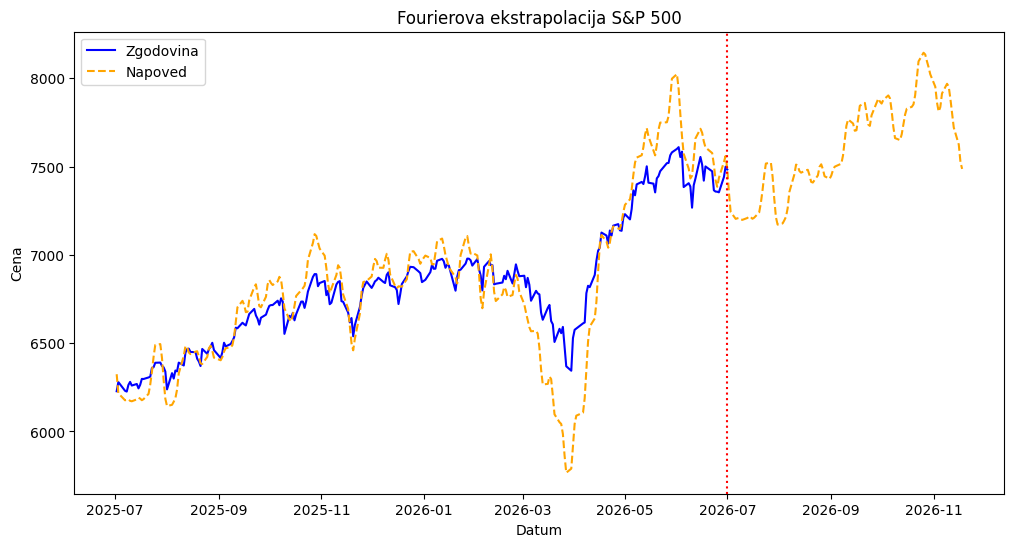

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(vsi_datumi[:stevilo_dni], y, label="Zgodovina", color="blue")
plt.plot(vsi_datumi, končna_napoved, label="Napoved", color="orange", linestyle="--")

# Dodamo navpično črto pri datumu, ko so bili podatki zbrani
plt.axvline(x=vsi_datumi[stevilo_dni - 1], color="red", linestyle=":")

plt.title("Fourierova ekstrapolacija S&P 500")
plt.xlabel("Datum")
plt.ylabel("Cena")
plt.legend()

plt.show()

Iz grafa je razvidno, da je naš približek dobro aproksimiral zgodovino indeksa S&P 500, ni pa približek točen. To je ustrezno, saj če bi vzeli veliko največjih frekvenc, bi se graf v prihodnosti popačil in imel nepravilno gibanje, zato vzamemo le največjih 50 frekvenc (to število lahko spreminjamo).
Spreminjamo lahko tudi napoved v prihodnosti, vendar ni smiselno vzeti preveč dni, saj je napoved smiselna le za krajše časovne intervale v prihodnosti. <br>
Kot vidimo, naš približek ocenjuje, da bo indeks rastel še naprej, vrhunec dosegel okoli novembra 2026, napoveduje pa padec vrednosti indeksa konec leta 2026. <br>

Seveda so ti modeli preveč preprosti, da bi zanesljivo lahko napovedali prihodnost vrednosti delnic oz. trga, saj trg delnic vključuje milijone ljudi, nepredvidljivih dogodkov, vremenskih pojavov, politike in drugih šumov, ki jih sama matematika ne zazna in ne more napovedati. Kljub temu pa veliko kvatitativnih agencij vseeno vključuje tudi matematično analizo periodičnih signalov, kot sem jo napravil tukaj, saj lahko razkrije matematično podlago mnogih dogodkov, ki vplivajo na podjetja in cene delnic.


### Sedaj poskusimo iz 500-tih podjetih, o katerih smo zbrali podatke ustvariti "povprečno" delnico

Kasneje bomo primerjali, kako se ta delnica primerja z indeksom S&P 500.


Pripravimo datoteko s cenami 500-ih delnic za obdelavo:


In [ ]:
CENE_500_DELNIC_VRSTICE = pd.read_csv("tickerji_plus_cene.csv", index_col="ticker")

CENE_500_DELNIC = CENE_500_DELNIC_VRSTICE.T
CENE_500_DELNIC.index = pd.to_datetime(CENE_500_DELNIC.index)

# Da ne dobimo 1970 bug
if "Datum" in CENE_500_DELNIC.columns:
    CENE_500_DELNIC = CENE_500_DELNIC.set_index("Datum")

if "Datum" in CENE_SP_500_STOLPCI.columns:
    CENE_SP_500_STOLPCI = CENE_SP_500_STOLPCI.set_index("Datum")

# Sortiramo od najstarejšega da najnovejšega
CENE_500_DELNIC = CENE_500_DELNIC.sort_index()
CENE_500_DELNIC = CENE_500_DELNIC.replace({",": ""}, regex=True).astype(float)

Pripravimo datoteko z ostalimi podatki in market cap spremenimo v število:


In [ ]:
PODATKI = pd.read_csv(
    "tickerji_s_podatki.csv", names=["ticker", "market_cap", "beta", "P/E"]
)
PODATKI = PODATKI.drop(0).reset_index(drop=True)
utezi = PODATKI[["ticker", "market_cap"]]


def pretvori_v_stevilko(vrednost):
    if pd.isna(vrednost):
        return 0

    vrednost_str = str(vrednost).upper().strip()

    if "T" in vrednost_str:
        return float(vrednost_str.replace("T", "")) * 1000000000000
    elif "B" in vrednost_str:
        return float(vrednost_str.replace("B", "")) * 1000000000
    elif "M" in vrednost_str:
        return float(vrednost_str.replace("M", "")) * 1000000
    else:
        return float(vrednost_str)


utezi["market_cap"] = utezi["market_cap"].apply(pretvori_v_stevilko)
PODATKI["market_cap"] = utezi["market_cap"]
PODATKI = PODATKI.set_index("ticker")

Sedaj z zbranimi podatki ustvarimo našo "povprečno" delnico in jo primerjamo z indeksom S&P 500:


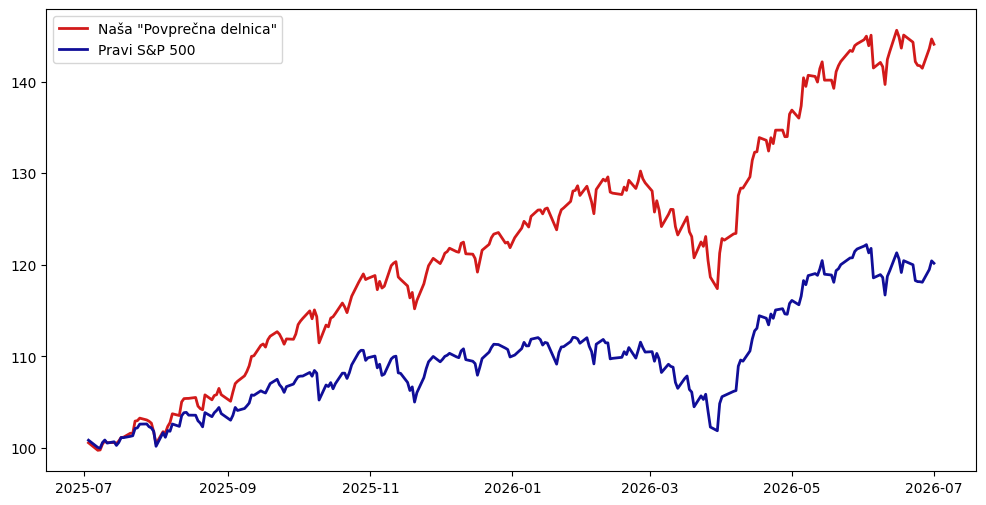

In [ ]:
# Vzamemo le podjetja, ki so bila javno razpisana na borzi celo zadnje leto
cene_polne = CENE_500_DELNIC.dropna(axis=1)

# Izračunamo uteži
utezi_norm = PODATKI.loc[cene_polne.columns, "market_cap"]
utezi_norm /= utezi_norm.sum()

# Izračunamo kumulativne indekse (oba štartata iz baze 100)
sinteticni_indeks = (1 + cene_polne.pct_change().dot(utezi_norm)).cumprod() * 100
pravi_sp500_indeks = (
    1 + CENE_SP_500_STOLPCI["Cena"].sort_index().pct_change()
).cumprod() * 100

# Izris grafa
plt.figure(figsize=(12, 6))
plt.plot(
    sinteticni_indeks, label='Naša "Povprečna delnica"', color="#D21A1A", linewidth=2
)
plt.plot(pravi_sp500_indeks, label="Pravi S&P 500", color="#100E98", linewidth=2)
plt.legend()
plt.show()

Iz grafa je razvidno, da se naša "povprečna" delnica dobro ujema in posnema obnašanje pravega indeksa S&P 500 - njeni padci in vrhovi se ujemajo s padci in vrhovi indeksa. <br>
Opažnja - zakaj je naša "povprečna delnica" toliko boljša od indeksa? Odgovor je pristranskost preživelih (survivour bias) - podjetja, ki smo jih imeli v našem vzorcu so največja danes, S&P 500 pa je v preteklosti vseboval še veliko delnic, ki jih danes ni več v njihovem naboru, zato zgodovinski graf primerjave naših delnic (preživelih) in vseh delnic (vključno s tistimi, ki jih je S&P 500 izključil iz svojega nabora) pokaže, da se je naša sintetična "povprečna" delnica v zadnjem letu odrezala bolje kot dejanski S&P 500.


## Nadaljujmo z analizo glavnih lastnosti delnic:


### Najprej poiščimo tiste delnice, ki čim bolje posnemajo celotni trg

Te delnice bomo poiskali s pomočjo beta markerja - bližje kot je beta marker številu 1, bolj se cena te delnice giblje kot celoten trg. Če je beta natanko 1, pomeni, da se cena delnice spremeni za 1% natanko tedaj, ko se celoten trg spremeni za 1%.


In [ ]:
beta_stolpec = PODATKI["beta"]


def razlika_do_1(niz):
    return abs(float(niz) - 1)


razlika_beta = beta_stolpec.apply(razlika_do_1)

najlizja_trgu = ""
min_razlika = None

for ticker, razlika in razlika_beta.items():
    if min_razlika is None or razlika < min_razlika:
        min_razlika = razlika
        vsi_najblizji = [ticker]

    elif razlika == min_razlika:
        vsi_najblizji.append(ticker)

print(f"Najdene delnice, ki najbolje posnemajo trg: {vsi_najblizji}")
print(f"Trg posnemajo z {min_razlika * 100}% napako (zaokroženo na dve decimalki)")

Najdene delnice, ki najbolje posnemajo trg: ['JPM', 'CSCO', 'JPM-PC', 'JPM-PD', 'KYCCF', 'USB', 'USB-PH', 'CNI', 'USB-PP']
Trg posnemajo z 0.0% napako (zaokroženo na dve decimalki)


Iz zgornjega vidimo, da je bilo najdenih kar nekaj delnic z beta markerjem 1. To je pričakovano, saj se beta marker običajno giblje med 0,5 in 1,5, v podatkih, ki smo jih vzeli, pa je bil beta zaokrožen na dve decimalki. Če bi želeli torej sintetično ustvariti čim manjšo množico delnic, ki posnemajo celoten trg (ali npr. S&P 500), bi kupili le zgornje delnice in pričakujemo lahko, da se bodo v prihodnosti obnašale podobno kot celoten trg. <br>

Na tak način tudi borzni posredniki prodajajo sintetične indekse, če posameznik kupi manjšo količino nekega indeksa - zaradi stroškov, ki pridejo z nakupom in prodajo vsake delnice, se borzni posrednik raje odloči, da namesto vseh delnic v indeksu kupi le nekaj tistih, ki posnemajo indeks in njegove glavne lastnosti (če npr. kupimo 10 evrov indeksa S&P 500, nam borzni posrednik ne bo kupil dejanskega malega deleža vsakega izmed 500-tih podjetij, vendar le nekaj izmed njih, ki ta indeks posnemajo).


Poglejmo si še kolikšen delež 500-tih največjih podjetih (glede na market cap) predstavlja največjih n podjetij, ko n spreminjamo:


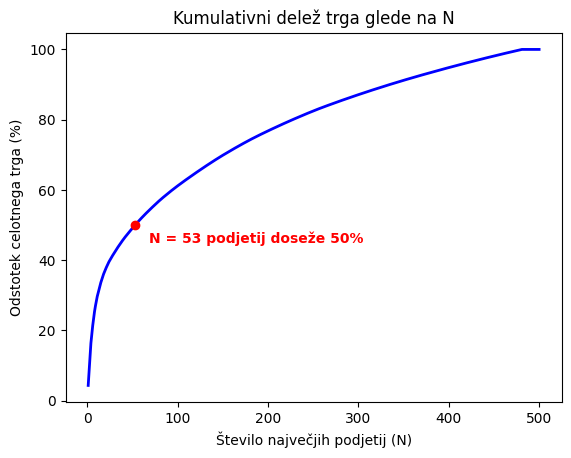

In [ ]:
urejen_mcap = PODATKI["market_cap"].sort_values(ascending=False)

kumulativni_procent = (urejen_mcap.cumsum() / urejen_mcap.sum()) * 100

n_osi = np.arange(1, 501)

# Poiščemo tisti n, ki je prvi, pri katerem število podjetij predstavlja več kot 50% trga
n_50 = len(kumulativni_procent[kumulativni_procent < 50]) + 1

plt.plot(n_osi, kumulativni_procent, color="blue", linewidth=2)
plt.title("Kumulativni delež trga glede na N")
plt.xlabel("Število največjih podjetij (N)")
plt.ylabel("Odstotek celotnega trga (%)")

plt.scatter(n_50, 50, color="red", zorder=5)
plt.text(
    n_50 + 15, 45, f"N = {n_50} podjetij doseže 50%", color="red", fontweight="bold"
)

plt.show()

Kot vidimo, se graf obnaša logaritemsko - to pomeni, da največja podjetja predstavljajo bistveno večji delež trga kot manjša podjetja. <br>
Vidimo tudi (označeno na grafu), da je le 53 največjih podjetij skupaj enako velikih kot ostalih 447 izmed največjih 500. <br>

To je trend, ki v zadnjih letih postaja vedno bolj očiten - večja podjetja postajajo še večja in dominirajo celotne trge. Danes največjih sedem podjetij v ZDA (The Magnificent Seven) predstavlja kar 33% delež celotnega indeksa S&P 500.


In [ ]:
# Za naslednji del odstranimo prednostne delnice - to so delnice s končnicami (-PA, -PC, -PH, -PI, -PP), ki imajo izkrivljene podatke za P/E - P/E razmerja teh delnic sicer lahko izračunamo, a so lahko izjemno nizka:
PODATKI = PODATKI[~PODATKI.index.str.contains(r"-P[A-Z]$", regex=True)]

Sedaj si oglejmo še P/E razmerja različnih delnic in kaj to lahko pomeni za te delnice.<br>
P/E razmerje izračunamo tako, da trenutno ceno delnice delimo z dobičkom na delnico.<br>
Načeloma visok/nizek P/E delnice nakazuje:

1. visok P/E (večji od 30) lahko nakazuje, da je delnica relativno draga, lahko pa tudi kaže na zaupanje vlagateljev v prihodnjo rast delnice
2. nizek P/E (manjši od 10) lahko nakazuje, da je delnica relativno poceni, lahko pa tudi pomeni, da vlagatelji menijo, da delnica ni stabilna


In [ ]:
pe_stolpec = PODATKI["P/E"].astype(float).sort_values(ascending=False).dropna()
najvecji_pe = pe_stolpec.head(10)
najmanjsi_pe = pe_stolpec.tail(10)

print("Delnice z največjimi P/E razmerji:")
for delnica, vrednost in najvecji_pe.items():
    print(f"{delnica} (P/E = {vrednost})")

print("")

print("Delnice z najmanjšimi P/E razmerji:")
for delnica, vrednost in najmanjsi_pe.items():
    print(f"{delnica} (P/E = {vrednost})")

Delnice z največjimi P/E razmerji:
DDOG (P/E = 651.7)
FUWAY (P/E = 413.38)
FUWAF (P/E = 401.09)
ARM (P/E = 393.3)
TSLA (P/E = 358.06)
PANW (P/E = 302.75)
ALAB (P/E = 286.03)
GLCNF (P/E = 227.33)
GLNCY (P/E = 227.0)
CGXYY (P/E = 184.47)

Delnice z najmanjšimi P/E razmerji:
TCANF (P/E = 5.47)
CICHY (P/E = 5.4)
BCMXY (P/E = 5.38)
PSTVY (P/E = 5.22)
IDCBF (P/E = 5.2)
ACGBF (P/E = 5.17)
PBR (P/E = 5.16)
PBR-A (P/E = 4.67)
CILJF (P/E = 4.65)
CMCSA (P/E = 4.61)


Iz zgornjega vidimo, da se P/E razmerja med različnimi podjetji bistveno razlikujejo. Pomemben faktor, ki ga nisem vključil v analizo je sektor, v katerem podjetje obratuje, saj je lahko v nekem sektorju P/E 50 zelo visok in pomeni, da je delnica relativno draga, v nekem drugem sektorju pa lahko pomeni, da je delnica pravilno ovrednotena ali celo poceni. Oglejo si dva ekstrema, ki smo ju dobili zgoraj:

- DDOG (Datadog) je vodilno podjetje sektorja nadzora Oblaka (Cloud monitoring) in zaradi pomanjkanja konkurence in popolne dominance na trgu, vlagatelji menijo, da je P/E 650 primeren, saj je zelo majhna možnost, da podjetje propade ali sploh dela z izgubo. Poleg tega DDOG večino profita reinvestira nazaj vase in v delavce, zato pri izračunu P/E razmerja dobiček na delnico ostane majhen in dobimo izkrivljeno visok P/E.

- CMCSA (Comcast) je podjetje, ki se ukvarja s telekomunikacijo, kabelsko televizijo in ostalimi internetnimi storitvami, je vodilni ponudnik interneta in kabelske televizije v Ameriki. Nizko P/E razmerje je posledica več dejavnikov, glavna od katerih sta dokončna prodaja Hulu-ja in upad kabelske televizije v zadnjih letih. Ker je Comcast prodal zadnji delež Hulu-ja Disney-u, so dobički na delnico veliko večji kot navadno, poleg tega pa zaradi upada kabelske televizije vlagatelji menijo, da jedrni posel tega podjetja zamira in zato ne zaupajo v prihodnjo donosnost podjetja. Ta dva dejavnika in še nekaj manjših so razlog, zakaj je P/E razmerje tako nizko. V resnici se je zgodovinsko razmerje P/E Comcasta gibalo okoli 10, a je zaradi nezaupanja vlagateljev in upada kabelske televizije danes to razmerje veliko manjše.


### Poglejmo si še razmerje med tveganjem in donosom različnih delnic in poskusimo na podlagi tega določiti "najboljše" delnice:

Tveganje bomo izračunali s pomočjo standardnega odklona, donos pa bomo dobili z izračunom povprečnih dnevnih donosov skozi celo leto.


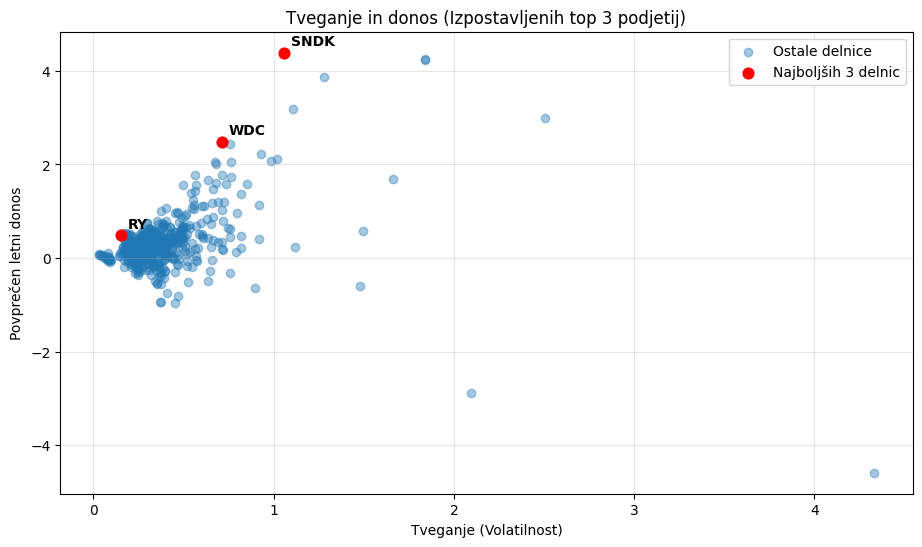

In [ ]:
# Letna donosnost (v zadnjem letu je bila borza odprta 252 dni)
donosi = CENE_500_DELNIC.pct_change().mean() * 252

# Letna volatilnost (252 korenimo, saj je standardni odklon koren variance)
tveganje = CENE_500_DELNIC.pct_change().std() * (252**0.5)

# Število najboljših delnic (lahko spreminjamo)
n = 3

# Podatke damo v skupno tabelo, kjer so indeksi tickerji delnic
df_analiza = pd.DataFrame({"Donos": donosi, "Tveganje": tveganje})

# Izračunamo razmerje
df_analiza["Razmerje"] = df_analiza["Donos"] / df_analiza["Tveganje"]

# Izberemo top n podjetij z najvišjim razmerjem
najboljša_podjetja = df_analiza.sort_values(by="Razmerje", ascending=False).head(n)

# Izrišemo graf
plt.figure(figsize=(11, 6))
plt.scatter(
    df_analiza["Tveganje"], df_analiza["Donos"], alpha=0.4, label="Ostale delnice"
)
plt.scatter(
    najboljša_podjetja["Tveganje"],
    najboljša_podjetja["Donos"],
    color="red",
    s=60,
    label=f"Najboljših {n} delnic",
)

# Z zanko se sprehodimo skozi najboljša podjetja in jim dodamo besedilo (ticker)
for ime_podjetja, vrstica in najboljša_podjetja.iterrows():
    plt.annotate(
        ime_podjetja,
        (vrstica["Tveganje"], vrstica["Donos"]),
        textcoords="offset points",
        xytext=(5, 5),  # Zamik besedila
        ha="left",  # Poravnava besedila
        color="black",
        fontweight="bold",
        fontsize=10,
    )

plt.xlabel("Tveganje (Volatilnost)")
plt.ylabel("Povprečen letni donos")
plt.title(f"Tveganje in donos (Izpostavljenih top {n} podjetij)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

Iz zgornjega vidimo, da so po razmerju tveganja in donosa najboljše delnice SNDK (Sandisk Corp), WDC (Western Digital Corp) in RY (Royal Bank of Canada) <br>
Sicer imajo delnice podobna razmerja med tveganjem in donosom, a iz grafa lahko razberemo razlike med njimi:

1. SNDK ima bistveno večje tveganje, hkrati pa tudi večji letni donos v zadnjem letu. SNDK je namreč eden izmed glavnih dobaviteljev Flash memory čipov, ki so zaradi hitro rastočega trga umetne inteligence in podatkovnih baz postali vedno bolj zaželjeni in dragi. Hkrati pa je trg umetne inteligence manj stabilen kot nekateri drugi trgi, zato je tudi tveganje pri naložbi v to delnico višje.

2. WDC ima srednje tveganje, a še vedno zelo dober povprečen letni donos. Podobno kot SNDK, tudi WDC proizvaja čipe, ki se uporabljajo v industriji umetne inteligence, a se poleg tega specializirajo tudi v drugih sektorjih programske opreme, zato je njihovo tveganje manjše, a zato tudi niso v celoti izkoristili donosa, ki bi ga lahko iz rasti umetne inteligence.

3. RY ima od teh treh najmanjše tveganje, a zato tudi manjši povprečen letni donos. Delnica RY je bila v zadnjem letu tako uspešna zaradi različnih razlogov, glavni od katerih so npr. pridobitev banke HSBC Bank Canada, ki se jim je zelo obrestovala, dobra razporeditev premoženja in finančna stabilnost ter vlaganje v umetno inteligenco... . Hkrati pa moramo upoštevati, da gre za banko, zato je povprečni letni donos manjši, saj banke strmijo k stabilnosti in rasti skozi leta, ne pa k hitri rasti in tveganju.
